## 1. Import Necessary Libraries

In [2]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split



## 2. Import Dataset

In [3]:
claiments_data = pd.read_csv('claimants_prediction.csv')
claiments_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


## 3. Data Understanding

In [4]:
claiments_data.shape

(1340, 7)

In [5]:
claiments_data.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [6]:
# for now drop the NaN and record the number of dropped rows
# inform or ask client about the dropped rows

In [7]:
claiments_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

## 4. Data Preparation

### 4.1 Data Cleaning

In [8]:
claiments_data.dropna(inplace=True)

# axis = 0 : row
# axis = 1 : column
# default the dropna() will take 0 for axis

In [9]:
claiments_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1334,34104,1,1.0,1.0,0.0,16.0,0.060
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [10]:
1340 - 1096 

244

In [11]:
# 244 rows dropped due to missing values

In [12]:
claiments_data.isna().sum()

CASENUM     0
ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

### 4.2 Separate your Input and Outputs

In [13]:
X = claiments_data.drop(labels=['CASENUM','ATTORNEY'],axis=1)
X

# CASENUM just like name --> useless in prediction
# attorney --> output

# during data cleaning apply common sense

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1334,1.0,1.0,0.0,16.0,0.060
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [14]:
y=claiments_data['ATTORNEY']
y

0       0
1       1
2       1
3       0
4       1
       ..
1334    1
1336    0
1337    1
1338    0
1339    1
Name: ATTORNEY, Length: 1096, dtype: int64

## 5. Model Building

### 5.1 Model Validation Techniques - Train Test Split

In [15]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,shuffle=True,random_state=34)

# random state: prevent the re-shuffling, even we shuffle many time still gets the same result

X_train

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
478,0.0,1.0,1.0,10.0,1.318
387,1.0,1.0,0.0,55.0,0.604
47,0.0,1.0,0.0,1.0,0.000
220,1.0,1.0,1.0,7.0,0.983
152,1.0,1.0,0.0,6.0,0.075
...,...,...,...,...,...
731,0.0,1.0,0.0,30.0,4.014
817,0.0,1.0,0.0,48.0,0.390
557,0.0,1.0,0.0,30.0,0.565
386,1.0,1.0,0.0,35.0,0.860


### 5.2 KFold CV

In [17]:
from sklearn.model_selection import KFold,cross_val_score

In [23]:
kfold = KFold(n_splits=5, shuffle=True, random_state=34)

cv_scores = cross_val_score(estimator = logistic_model, X=X,y=y,cv=kfold)

print(cv_scores)
print('Overall Accurary:',cv_scores.mean().round(2))
print('Overall Standard Deviation:',cv_scores.std().round(2))

[0.68181818 0.7260274  0.74429224 0.69863014 0.6803653 ]
Overall Accurary: 0.71
Overall Standard Deviation: 0.03


### 5.3 LOOCV

In [26]:
from sklearn.model_selection import LeaveOneOut

loocv =LeaveOneOut()

cv_scores = cross_val_score(estimator = logistic_model, X=X,y=y,cv=loocv)

print(cv_scores)
print('Overall Accurary:',cv_scores.mean().round(2))
print('Overall Standard Deviation:',cv_scores.std().round(2))

[1. 1. 1. ... 1. 1. 1.]
Overall Accurary: 0.7
Overall Standard Deviation: 0.46


In [18]:
logistic_model = LogisticRegression()

## 6. Model Training

In [19]:
logistic_model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

## 7. Model Testing

### Training data

In [17]:
y_pred_train = logistic_model.predict(X_train)
y_pred_train

array([0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1,

### Test data

In [18]:
y_pred_test = logistic_model.predict(X_test)
y_pred_test

array([0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0])

In [19]:
y_pred = logistic_model.predict(X)
y_pred

array([0, 1, 1, ..., 1, 0, 1], shape=(1096,))

In [21]:
claiments_data['Predicted_Output']=y_pred
claiments_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS,Predicted_Output
0,5,0,0.0,1.0,0.0,50.0,34.940,0
1,3,1,1.0,0.0,0.0,18.0,0.891,1
2,66,1,0.0,1.0,0.0,5.0,0.330,1
3,70,0,0.0,1.0,1.0,31.0,0.037,0
4,96,1,0.0,1.0,0.0,30.0,0.038,1
...,...,...,...,...,...,...,...,...
1334,34104,1,1.0,1.0,0.0,16.0,0.060,1
1336,34110,0,1.0,1.0,0.0,46.0,3.705,0
1337,34113,1,1.0,1.0,0.0,39.0,0.099,1
1338,34145,0,1.0,0.0,0.0,8.0,3.177,0


## 8. Model Evaluation

In [27]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_curve,roc_auc_score

### 8.1 Training Data's Evaluation Metrics

In [24]:
print(confusion_matrix(y_train,y_pred_train))

[[297 156]
 [ 99 324]]


In [26]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.75      0.66      0.70       453
           1       0.68      0.77      0.72       423

    accuracy                           0.71       876
   macro avg       0.71      0.71      0.71       876
weighted avg       0.71      0.71      0.71       876



### 8.2 ROC Curve - Receiver Operating Characteristics

AUC - Area Under this Curve

0.7107932929406792


Text(0, 0.5, 'True Positive Rate')

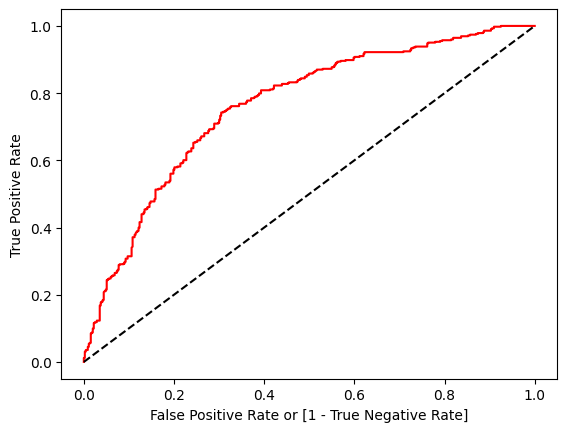

In [29]:
fpr, tpr, thresholds = roc_curve(y_train, logistic_model.predict_proba(X_train)[:,1])

auc = roc_auc_score(y_train,y_pred_train)

print(auc)

import matplotlib.pyplot as plt
plt.plot(fpr,tpr, color='red', label='logit model( area = %0.2f)'%auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')

### Training Accuracy

In [26]:
accuracy_score(y_train,y_pred_train)

0.7134703196347032

### 8.2 Test Data's Evaluation Metrics

In [31]:
print(confusion_matrix(y_test,y_pred_test))

[[78 47]
 [23 72]]


### Test Accuracy

In [30]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.77      0.62      0.69       125
           1       0.61      0.76      0.67        95

    accuracy                           0.68       220
   macro avg       0.69      0.69      0.68       220
weighted avg       0.70      0.68      0.68       220



0.6909473684210526


Text(0, 0.5, 'True Positive Rate')

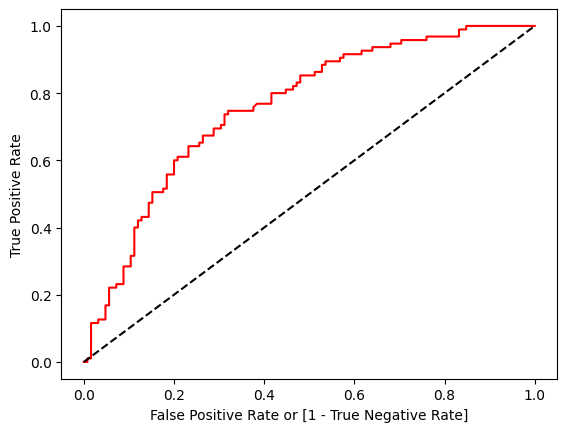

In [32]:
fpr, tpr, thresholds = roc_curve(y_test, logistic_model.predict_proba(X_test)[:,1])

auc = roc_auc_score(y_test,y_pred_test)

print(auc)

import matplotlib.pyplot as plt
plt.plot(fpr,tpr, color='red', label='logit model( area = %0.2f)'%auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')

In [27]:
accuracy_score(y_test,y_pred_test)

0.7

In [28]:
accuracy_score(y,y_pred)

0.708029197080292

## 9. Model Deployment

In [30]:
from pickle import dump


In [31]:
dump(logistic_model,file=open('claiments.pkl','wb'))

In [32]:
# if want to load the pkl file 

In [33]:
from pickle import load

In [35]:
logistic_intel=load(file=open('claiments.pkl','rb'))

In [36]:
logistic_intel

LogisticRegression()

## THE END